<a href="https://colab.research.google.com/github/maryamhasnaasyamila/machine-learning/blob/tugas/praktikum/praktikum13/notebook/Maryam_Hasnaa'_Syamila_0110222067_PraktikumMandiri13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### **1. Download Data dari Kaggle**

In [ ]:
# install librray kaggle
!pip install kaggle

In [ ]:
# sinkronisasi dengan google drive
from google.colab import drive
drive.mount('/content/drive')

# path API json di Google Drive
kaggle = "/content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum13/datasets/kaggle.json"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p ~/.kaggle
!cp "{kaggle}" ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
  0% 0.00/66.7M [00:00<?, ?B/s]
100% 66.7M/66.7M [00:00<00:00, 1.41GB/s]


In [ ]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = "datasets"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [ ]:
data_0 = os.listdir('/content/datasets/0')
data_1 = os.listdir('/content/datasets/1')
data_2 = os.listdir('/content/datasets/2')
data_3 = os.listdir('/content/datasets/3')
data_4 = os.listdir('/content/datasets/4')
data_5 = os.listdir('/content/datasets/5')
data_6 = os.listdir('/content/datasets/6')
data_7 = os.listdir('/content/datasets/7')
data_8 = os.listdir('/content/datasets/8')
data_9 = os.listdir('/content/datasets/9')

In [ ]:
len(data_0)

2236

#### **2. Import Library**

In [ ]:
# Import library utama
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

#### **3. Load Dataset & Preprocessing**

In [ ]:
# Path folder dataset hasil ekstraksi
dataset_path = "/content/datasets"

X = []   # untuk menyimpan citra
y = []   # untuk menyimpan label (0-9)

# Loop folder label (0 sampai 9)
for label in range(10):
    folder = os.path.join(dataset_path, str(label))

    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)

        # baca citra grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # ubah ke ukuran standar 28x28 seperti MNIST
        img = cv2.resize(img, (28, 28))

        # invert warna (sering diperlukan untuk dataset kaggle)
        img = cv2.bitwise_not(img)

        # threshold untuk mempertegas bentuk angka
        _, img = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)

        # normalisasi pixel 0–255 → 0–1
        img = img / 255.0

        X.append(img)
        y.append(label)

# ubah menjadi numpy
X = np.array(X)
y = np.array(y)

print("Shape dataset:", X.shape)
print("Total sampel:", len(X))

Shape dataset: (21555, 28, 28)
Total sampel: 21555


#### **4. One-hot enoding label + reshape**

In [ ]:
# ubah label menjadi one-hot (multi-class 10 kelas)
y_encoded = to_categorical(y, num_classes=10)

# flatten gambar 28x28 menjadi 784 fitur
X_flat = X.reshape(len(X), 28*28)

print("X shape:", X_flat.shape)
print("y shape:", y_encoded.shape)

X shape: (21555, 784)
y shape: (21555, 10)


#### **5. Split Data Train & Test**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y_encoded,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,
    shuffle=True
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (17244, 784) (17244, 10)
Test : (4311, 784) (4311, 10)


#### **6. Bangun Model MLP (ANN)**

In [ ]:
model = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dropout(0.2),

    Dense(256, activation='relu'),
    Dropout(0.2),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')   # output multi-class
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,050 (2.19 MB)

 Trainable params: 575,050 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

#### **7. Kompilasi Model**

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#### **8. Training Model**

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.2355 - loss: 2.0934 - val_accuracy: 0.4885 - val_loss: 1.5304
Epoch 2/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5396 - loss: 1.3745 - val_accuracy: 0.5935 - val_loss: 1.2290
Epoch 3/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.6891 - loss: 0.9454 - val_accuracy: 0.6454 - val_loss: 1.0785
Epoch 4/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7858 - loss: 0.6680 - val_accuracy: 0.6593 - val_loss: 1.0528
Epoch 5/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8555 - loss: 0.4624 - val_accuracy: 0.6590 - val_loss: 1.0984
Epoch 6/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8902 - loss: 0.3561 - val_accuracy: 0.6614 - val_loss: 1.1596
Epoch 7/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9130 - loss: 0.2733 - val_accuracy: 0.6677 - val_loss: 1.2472
Epoch 8/30
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9318 - loss: 0.2195 - val_accu

#### **9. Evaluasi Model**

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6702 - loss: 1.9702
Test Loss: 1.8641406297683716
Test Accuracy: 0.673857569694519


#### **10. Visualisasi Akurasi & Loss**

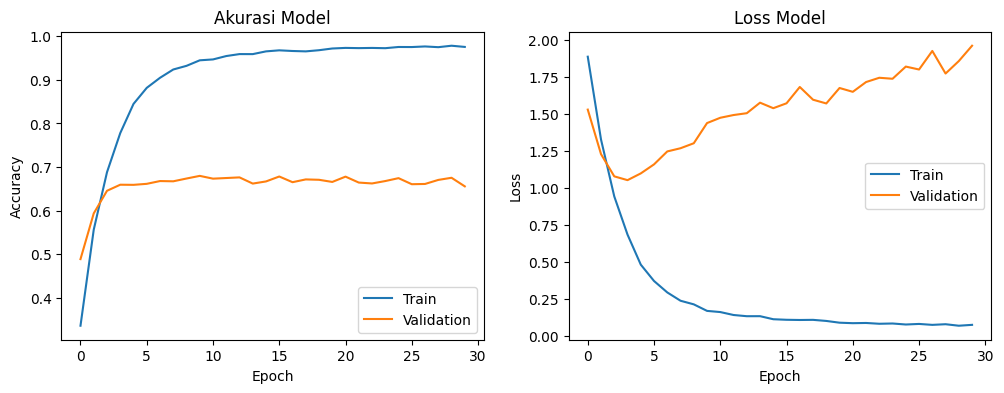

In [ ]:
plt.figure(figsize=(12,4))

# Akurasi
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Akurasi Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()